# A princípio iremos baixar e concatenar 6 base de dados do Kaggle:

https://www.kaggle.com/datasets/hasibur013/diabetes-dataset<br>
https://www.kaggle.com/datasets/anupriyaparakale/diabetes-detection<br>
https://www.kaggle.com/datasets/karanshah1910/diabetes-prediction<br>
https://www.kaggle.com/datasets/ehsankhani/diabetes-health-indicators-dataset<br>
https://www.kaggle.com/datasets/nanditapore/healthcare-diabetes<br>
https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database<br>

In [1]:
import kagglehub
import pandas as pd
import os

datasets_names = [
    "hasibur013/diabetes-dataset",
    "anupriyaparakale/diabetes-detection",
    "karanshah1910/diabetes-prediction",
    "ehsankhani/diabetes-health-indicators-dataset",
    "nanditapore/healthcare-diabetes",
    "uciml/pima-indians-diabetes-database"
]

columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'IMC', 'DPF', 'Age', 'Outcome']

# Cria uma lista com todos datasets
datasets = [];
for i in range(len(datasets_names)):
  path = kagglehub.dataset_download(datasets_names[i])
  filename = os.listdir(path)[0]
  filepath = os.path.join(path, filename)
  print(f"Attempting to read: {filepath}")
  datasets.append(pd.read_csv(filepath))
  print(f"{datasets_names[i]} has {datasets[-1].shape} (rows, columns) and columns: {datasets[-1].columns.tolist()}\n")


Using Colab cache for faster access to the 'diabetes-dataset' dataset.
Attempting to read: /kaggle/input/diabetes-dataset/diabetes_dataset.csv
hasibur013/diabetes-dataset has (768, 9) (rows, columns) and columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Using Colab cache for faster access to the 'diabetes-detection' dataset.
Attempting to read: /kaggle/input/diabetes-detection/health diabetes.csv
anupriyaparakale/diabetes-detection has (774, 9) (rows, columns) and columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Using Colab cache for faster access to the 'diabetes-prediction' dataset.
Attempting to read: /kaggle/input/diabetes-prediction/diabetes.csv
karanshah1910/diabetes-prediction has (768, 9) (rows, columns) and columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigr

In [ ]:
# Verifica se os datasets são iguais
repeated_datasets = []
for i in range(len(datasets)):
  for j in range(i+1, len(datasets)):
    # Normaliza nomes de coluna para permitir comparação mesmo com pequenas diferenças de nome
    df_i_normalized = datasets[i].rename(columns={'DiabetesPedigreeFunction': 'DPF'})
    df_j_normalized = datasets[j].rename(columns={'DiabetesPedigreeFunction': 'DPF'})

    # Garante que ambos os dataframes tenham as mesmas colunas na mesma ordem para comparação exata
    common_cols = list(set(df_i_normalized.columns) & set(df_j_normalized.columns))
    df_i_common = df_i_normalized[common_cols].sort_index(axis=1)
    df_j_common = df_j_normalized[common_cols].sort_index(axis=1)

    if (df_i_common.equals(df_j_common)):
      repeated_datasets.append(j) # Adiciona o índice do dataset repetido
      print(f"Dataset {datasets_names[i]} e {datasets_names[j]} são iguais (ou muito semelhantes nas colunas comuns).")


# Remove os datasets repetidos da lista de datasets
unique_datasets = [datasets[i] for i in range(len(datasets)) if i not in repeated_datasets]

# Agora, concatena os datasets únicos
# Primeiro, padronize os nomes das colunas e a ordem, se necessário, antes da concatenação.

processed_unique_datasets = []
for df_item in unique_datasets:
    # Renomeia 'DiabetesPedigreeFunction' para 'DPF' se existir
    if 'DiabetesPedigreeFunction' in df_item.columns:
        df_item = df_item.rename(columns={'DiabetesPedigreeFunction': 'DPF'})
    if 'BMI' in df_item.columns:
        df_item = df_item.rename(columns={'BMI': 'IMC'})

    # Reindexa o DataFrame para ter as colunas desejadas na ordem correta.
    # Colunas que não existirem em df_item serão preenchidas com NaN.
    # Colunas em df_item que não estiverem na lista `columns` serão removidas.
    df_item = df_item.reindex(columns=columns)
    processed_unique_datasets.append(df_item)

# Concatena os datasets processados
df = pd.concat(processed_unique_datasets, ignore_index=True)

print("\nDatasets únicos combinados:")
for i in range(len(datasets)):
  if i not in repeated_datasets:
    print(f"    {datasets_names[i]}")

print(f"\nShape do DataFrame combinado: {df.shape}")

print("\nPrimeiras 5 linhas do DataFrame combinado:")
display(df.head())

print("\nInformações do DataFrame combinado:")
df.info()

Dataset hasibur013/diabetes-dataset e karanshah1910/diabetes-prediction são iguais (ou muito semelhantes nas colunas comuns).
Dataset hasibur013/diabetes-dataset e ehsankhani/diabetes-health-indicators-dataset são iguais (ou muito semelhantes nas colunas comuns).
Dataset hasibur013/diabetes-dataset e uciml/pima-indians-diabetes-database são iguais (ou muito semelhantes nas colunas comuns).
Dataset karanshah1910/diabetes-prediction e ehsankhani/diabetes-health-indicators-dataset são iguais (ou muito semelhantes nas colunas comuns).
Dataset karanshah1910/diabetes-prediction e uciml/pima-indians-diabetes-database são iguais (ou muito semelhantes nas colunas comuns).
Dataset ehsankhani/diabetes-health-indicators-dataset e uciml/pima-indians-diabetes-database são iguais (ou muito semelhantes nas colunas comuns).

Datasets únicos combinados:
    hasibur013/diabetes-dataset
    anupriyaparakale/diabetes-detection
    nanditapore/healthcare-diabetes

Shape do DataFrame combinado: (4310, 9)

Pr

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,IMC,DPF,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Informações do DataFrame combinado:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4310 entries, 0 to 4309
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pregnancies    4310 non-null   int64  
 1   Glucose        4310 non-null   int64  
 2   BloodPressure  4310 non-null   int64  
 3   SkinThickness  4310 non-null   int64  
 4   Insulin        4310 non-null   int64  
 5   IMC            4310 non-null   float64
 6   DPF            4310 non-null   float64
 7   Age            4310 non-null   int64  
 8   Outcome        4310 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 303.2 KB


##Remoção de linhas duplicadas

In [ ]:
print(f"Número de linhas antes da remoção de duplicatas: {df.shape[0]}")

duplicated_rows_count = df.duplicated().sum()
print(f"Número de linhas duplicadas: {duplicated_rows_count}")

if duplicated_rows_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicatas removidas. Número de linhas após remoção: {df.shape[0]}")
else:
    print("Nenhuma duplicata encontrada.")

Número de linhas antes da remoção de duplicatas: 4310
Número de linhas duplicadas: 3532
Duplicatas removidas. Número de linhas após remoção: 778


# Agora vamos verificar se existem valores iguais a zero onde é clinicamente impossível e substituí-los pela mediana da coluna

--- Análise de Valores Zero (Possíveis Missing Values) ---
Glucose: 5 zeros (0.64%)
BloodPressure: 36 zeros (4.63%)
SkinThickness: 229 zeros (29.43%)
Insulin: 377 zeros (48.46%)
IMC: 11 zeros (1.41%)


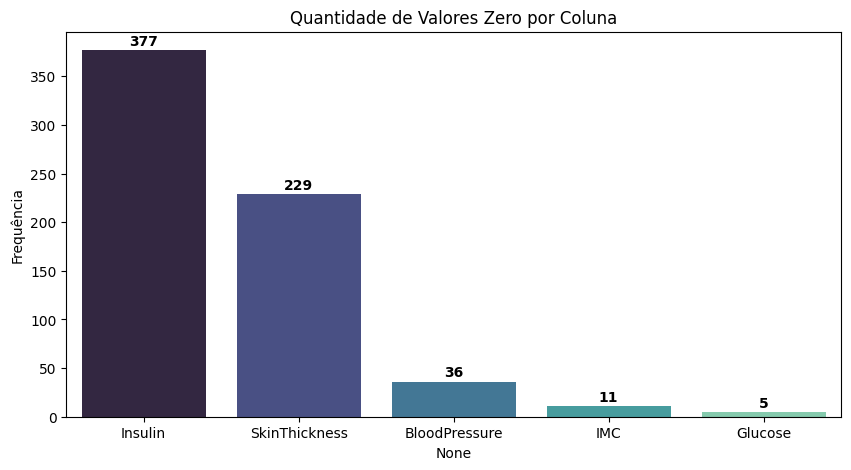



--- Contagem de valores nulos após substituição dos zeros por NaN ---


,0
Glucose,5
BloodPressure,36
SkinThickness,229
Insulin,377
IMC,11


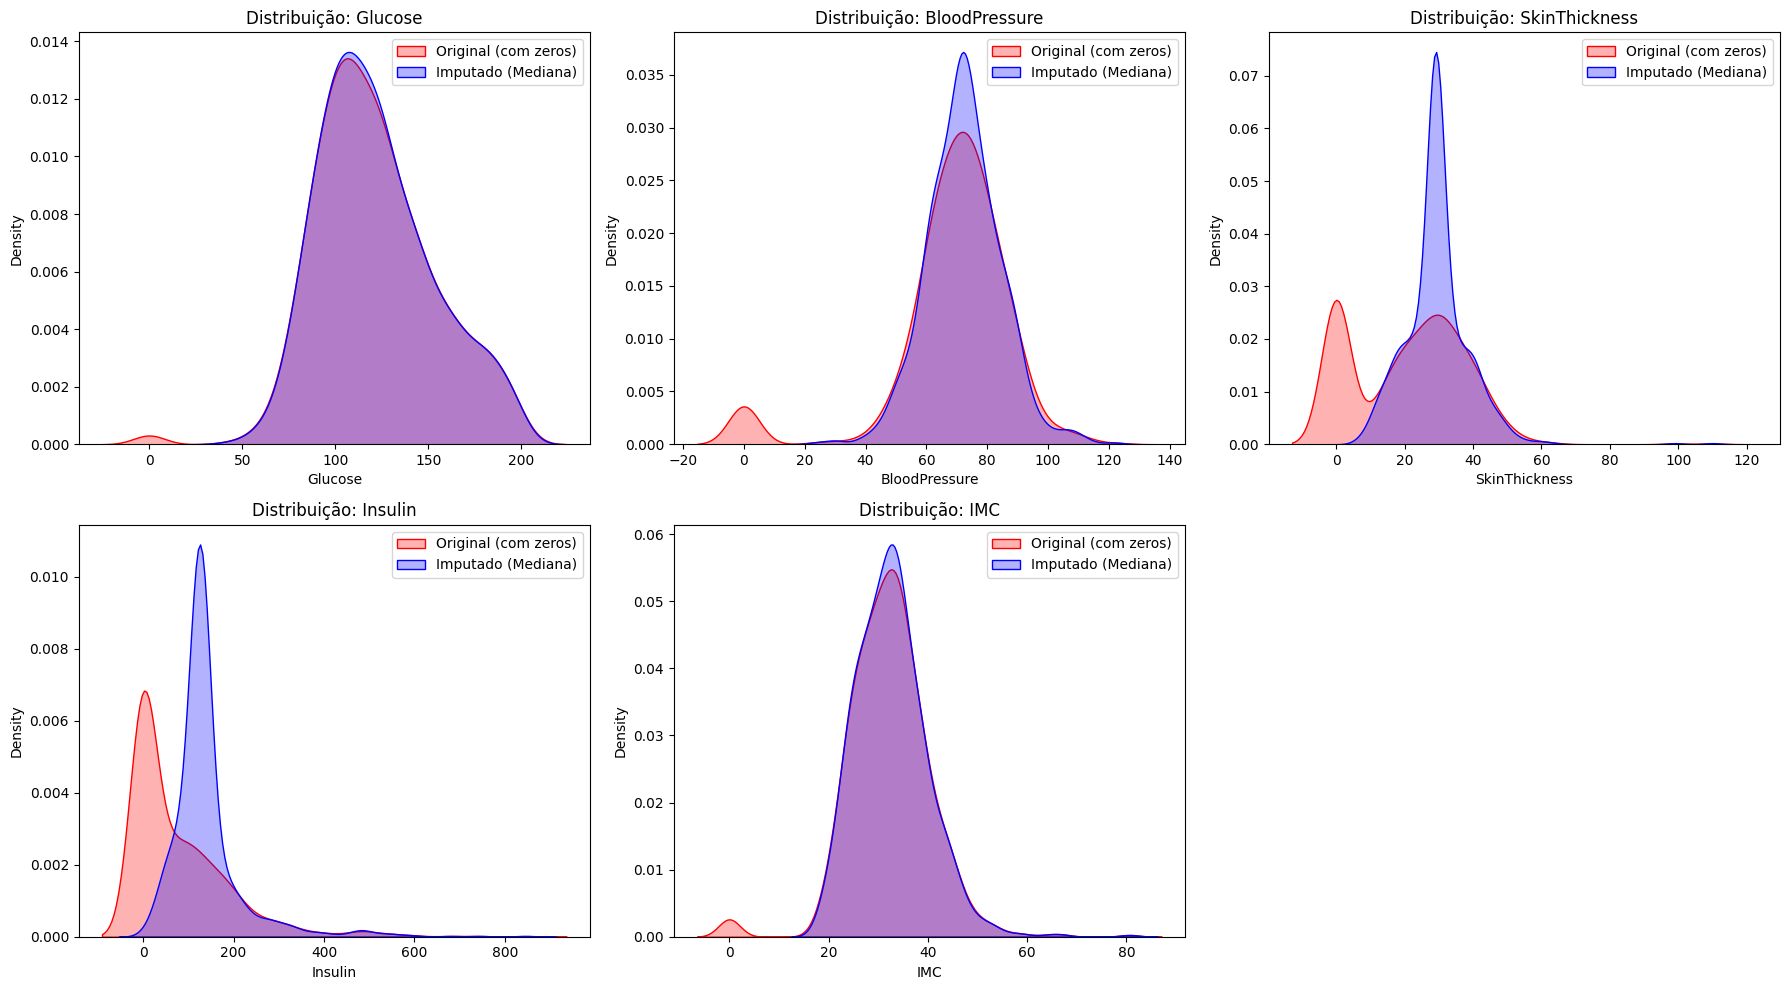



--- Contagem de valores nulos após substituição do NaN pelas medianas ---


,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
IMC,0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.impute import SimpleImputer

# Substituindo zeros por NaN nas colunas onde o zero é clinicamente impossível
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'IMC']

print('--- Análise de Valores Zero (Possíveis Missing Values) ---')
for col in cols_to_fix:
    zeros_count = (df[col] == 0).sum()
    percentage = (zeros_count / len(df)) * 100
    print(f'{col}: {zeros_count} zeros ({percentage:.2f}%)')

# Visualização da presença de zeros
plt.figure(figsize=(10, 5))
zeros_df = (df[cols_to_fix] == 0).sum().sort_values(ascending=False)
sns.barplot(x=zeros_df.index, y=zeros_df.values, hue=zeros_df.index, palette='mako', legend=False)
plt.title('Quantidade de Valores Zero por Coluna')
plt.ylabel('Frequência')

# Adicionando os rótulos de texto no topo das barras
for i, val in enumerate(zeros_df.values):
    plt.text(i, val + 5, str(val), horizontalalignment='center', fontweight='bold')

plt.show()

# Criando uma cópia para preservar os dados originais se necessário
df_clean = df.copy()

for col in cols_to_fix:
    df_clean[col] = df_clean[col].replace(0, np.nan)

print("\n\n--- Contagem de valores nulos após substituição dos zeros por NaN ---")
display(df_clean[cols_to_fix].isnull().sum())

# Substituindos os valores NaN pela mediana
imputer = SimpleImputer(strategy='median')
imputer.fit_transform(df_clean[cols_to_fix])
df_clean[cols_to_fix] = imputer.transform(df_clean[cols_to_fix])

# Visualização de Comparação (Antes vs Depois)Z
# Alterado de (1, 3) para (2, 3) para acomodar 5 plots (5 colunas em cols_to_fix)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # Achata o array de eixos para facilitar a iteração

for i, col in enumerate(cols_to_fix):
    sns.kdeplot(df[col], ax=axes[i], label='Original (com zeros)', color='red', fill=True, alpha=0.3)
    sns.kdeplot(df_clean[col], ax=axes[i], label='Imputado (Mediana)', color='blue', fill=True, alpha=0.3)
    axes[i].set_title(f'Distribuição: {col}')
    axes[i].legend()

# Remove subplots vazios, se houver
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

print("\n\n--- Contagem de valores nulos após substituição do NaN pelas medianas ---")
display(df_clean[cols_to_fix].isnull().sum())

### Observação de Qualidade:
Note que colunas como **Insulin** e **SkinThickness** possuem uma quantidade massiva de zeros. Em um contexto médico, isso sugere que os dados não foram coletados para esses pacientes, e tratar esses zeros como valores reais pode enviesar o modelo futuramente.

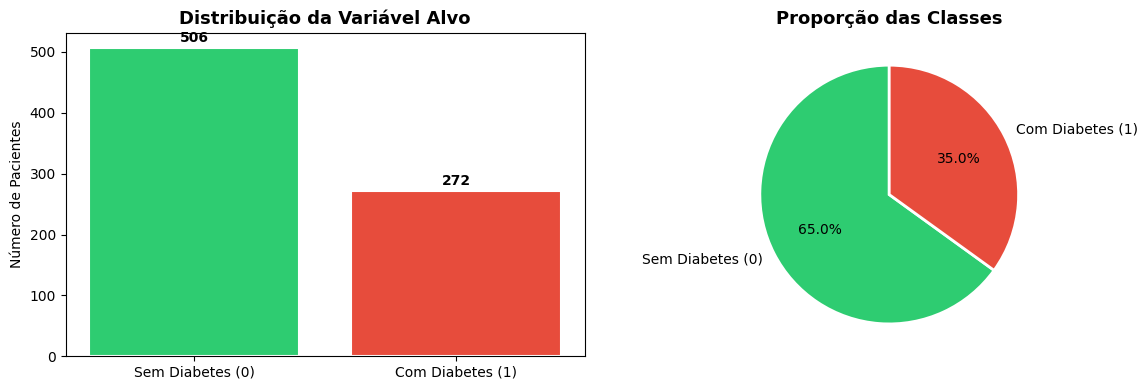


 Sem Diabetes: 506 (65.0%)
 Com Diabetes:  272 (35.0%)
  Desbalanceamento detectado: razão 1.86:1


In [ ]:
# Distribuição da variável alvo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
counts = df_clean['Outcome'].value_counts()
labels = ['Sem Diabetes (0)', 'Com Diabetes (1)']
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribuição da Variável Alvo', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de Pacientes')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontweight='bold')

# Gráfico de pizza
axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção das Classes', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('distribuicao_alvo.png', bbox_inches='tight')
plt.show()

print(f"\n Sem Diabetes: {counts[0]} ({counts[0]/len(df_clean)*100:.1f}%)")
print(f" Com Diabetes:  {counts[1]} ({counts[1]/len(df_clean)*100:.1f}%)")
print(f"  Desbalanceamento detectado: razão {counts[0]/counts[1]:.2f}:1")


# Visualização dos Outliers com boxplots

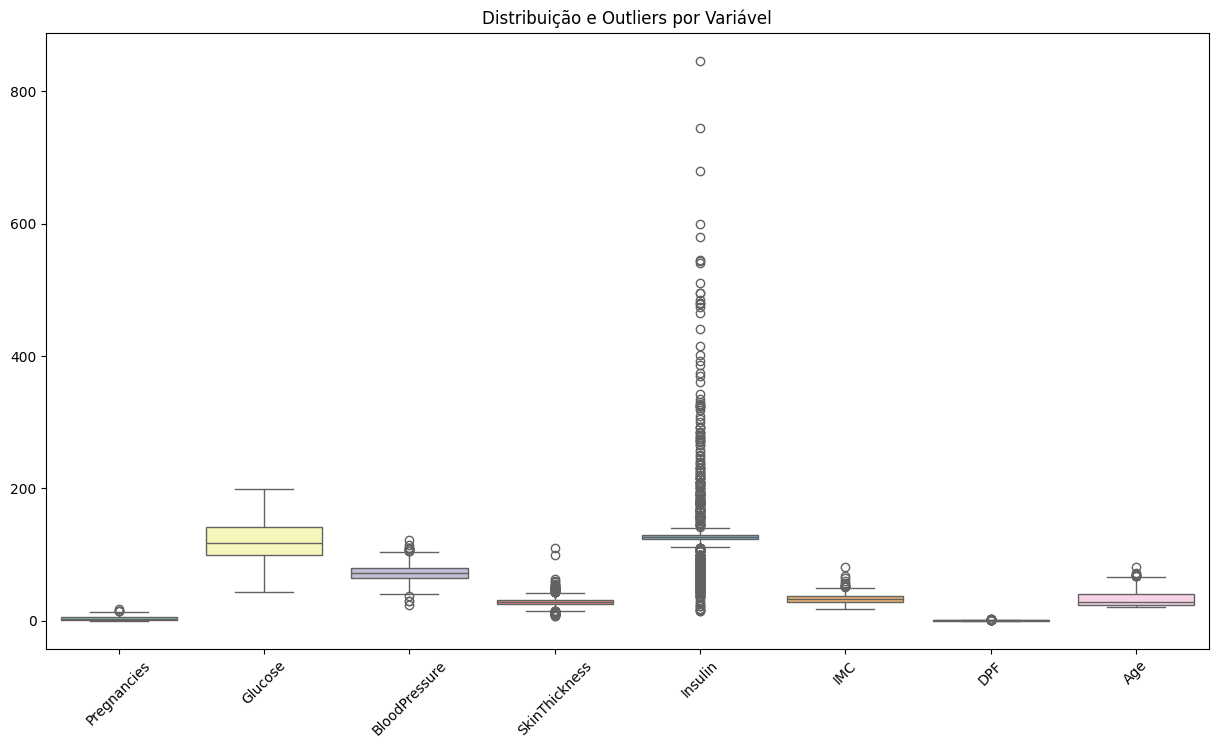

In [ ]:
# Analisando a amplitude dos dados para identificar valores extremos
plt.figure(figsize=(15, 8))
# Normalizando visualmente para comparação (apenas para o boxplot)
df_unscaled = df_clean.drop(columns=['Outcome'])
sns.boxplot(data=df_unscaled, palette='Set3')
plt.title('Distribuição e Outliers por Variável')
plt.xticks(rotation=45)
plt.show()


## Tratamento de Outliers e Transformação de Dados

Com base nas observações anteriores sobre a presença de outliers extremos em `Insulin` e `SkinThickness`, e a não-normalidade da maioria das variáveis, aplicaremos as seguintes técnicas para melhorar a qualidade e distribuição dos dados:

1.  **Capping (Winsorização)**: Limitaremos os valores extremos das colunas `Insulin` e `SkinThickness` ao seu 99º percentil para reduzir o impacto de outliers sem removê-los completamente.

In [ ]:
# Capping (Winsorization) dos Outliers usando o 99º percentil
# para Insulin e SkinThickness

print("\nEstatísticas descritivas antes do capping:")
display(df_clean[['Insulin', 'SkinThickness']].describe())

for col in ['Insulin', 'SkinThickness']:
    upper_bound = df_clean[col].quantile(0.99)
    df_clean[col] = np.where(df_clean[col] > upper_bound, upper_bound, df_clean[col])

print("\nEstatísticas descritivas após o capping:")
display(df_clean[['Insulin', 'SkinThickness']].describe())



Estatísticas descritivas antes do capping:


,Insulin,SkinThickness
count,778.000000,778.000000
mean,141.444730,29.299486
std,85.978838,9.307780
min,14.000000,7.000000
25%,122.750000,25.000000
50%,126.000000,29.000000
75%,130.000000,32.000000
max,846.000000,110.000000



Estatísticas descritivas após o capping:


,Insulin,SkinThickness
count,778.00000,778.000000
mean,140.23419,29.125553
std,78.89412,8.437728
min,14.00000,7.000000
25%,122.75000,25.000000
50%,126.00000,29.000000
75%,130.00000,32.000000
max,516.90000,52.460000


## Agora vamos analisar a distribuição com histogramas.

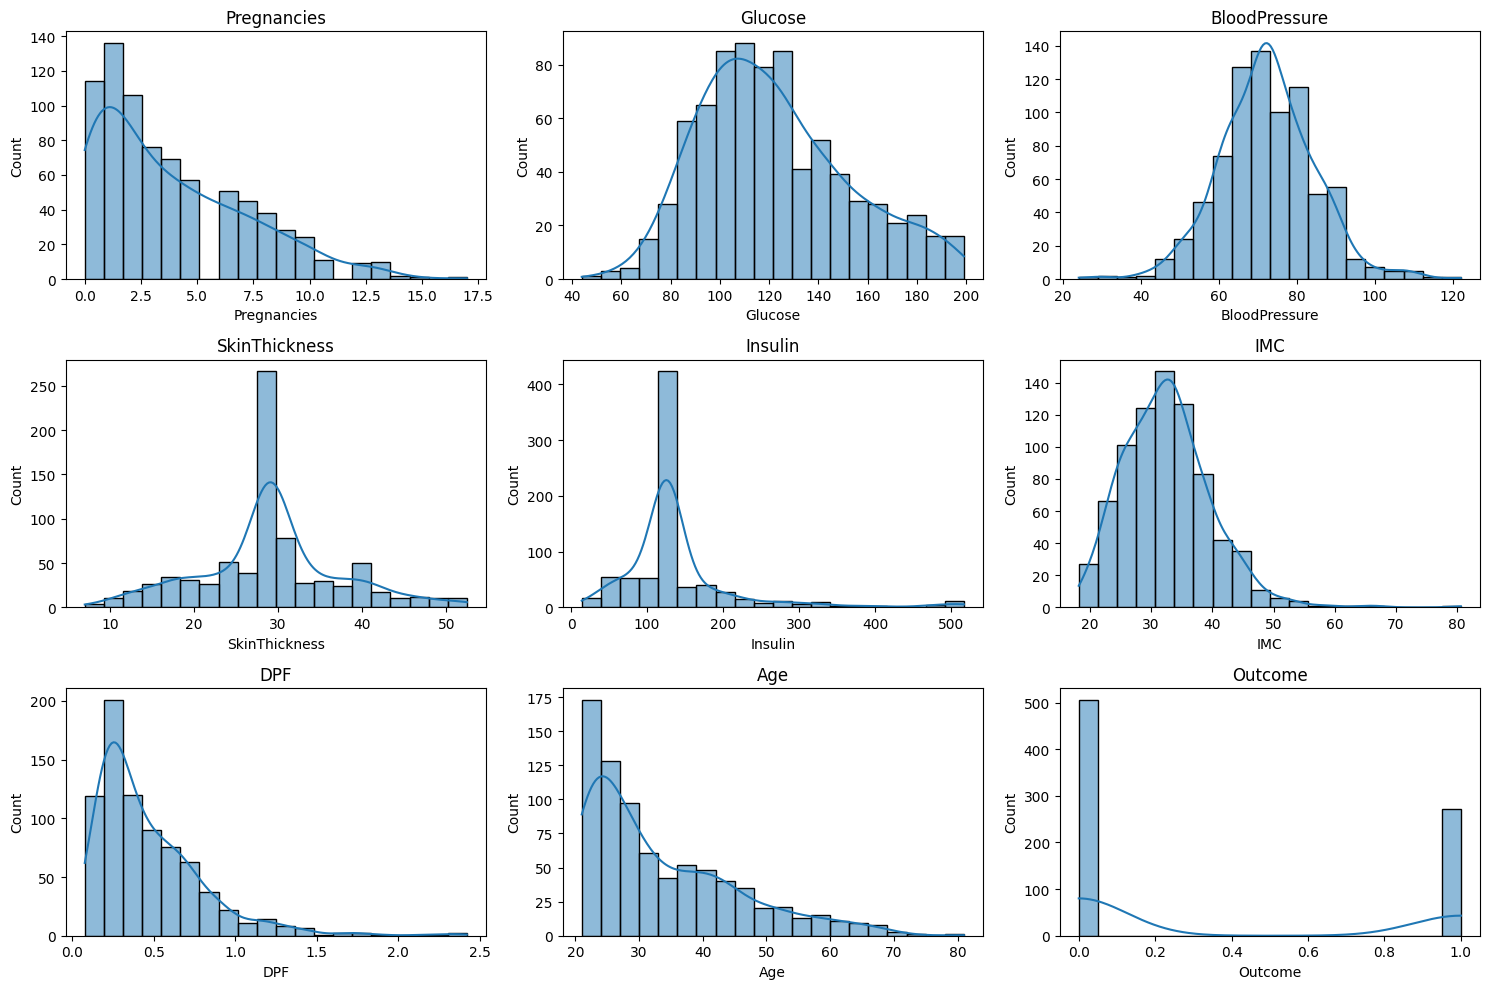

In [ ]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(df_clean.columns[:9]):
    plt.subplot(3, 3, i + 1)  # Aqui, ajustei para 3 linhas e 3 colunas
    sns.histplot(df_clean[col], bins=20, kde=True)
    plt.title(f'{col}')

plt.tight_layout()
plt.show()

# O código abaixo ajuda a interpretar se a distribuição é normal.

In [ ]:
from scipy.stats import shapiro

for column in df_clean.columns:
    stat, p_value = shapiro(df_clean[column])
    print(f'Variável: {column}, Estatística de teste: {stat}, Valor p: {p_value}')

    # Interpreta o valor p para determinar se a variável segue uma distribuição normal
    if p_value > 0.05:
        print(f'A variável {column} parece seguir uma distribuição normal.\n')
    else:
        print(f'A variável {column} não parece seguir uma distribuição normal.\n')




Variável: Pregnancies, Estatística de teste: 0.9033113757145486, Valor p: 9.166994370720798e-22
A variável Pregnancies não parece seguir uma distribuição normal.

Variável: Glucose, Estatística de teste: 0.9706225222096622, Valor p: 2.1316803750353392e-11
A variável Glucose não parece seguir uma distribuição normal.

Variável: BloodPressure, Estatística de teste: 0.9883236883662703, Valor p: 7.339947733215318e-06
A variável BloodPressure não parece seguir uma distribuição normal.

Variável: SkinThickness, Estatística de teste: 0.9560724271103024, Valor p: 1.720097213671059e-14
A variável SkinThickness não parece seguir uma distribuição normal.

Variável: Insulin, Estatística de teste: 0.6916519158968786, Valor p: 2.2536939950739613e-35
A variável Insulin não parece seguir uma distribuição normal.

Variável: IMC, Estatística de teste: 0.9578782134589555, Valor p: 3.781611938135408e-14
A variável IMC não parece seguir uma distribuição normal.

Variável: DPF, Estatística de teste: 0.83807

# Análise de correlação entre os dados e o diagnóstico (Outcome)

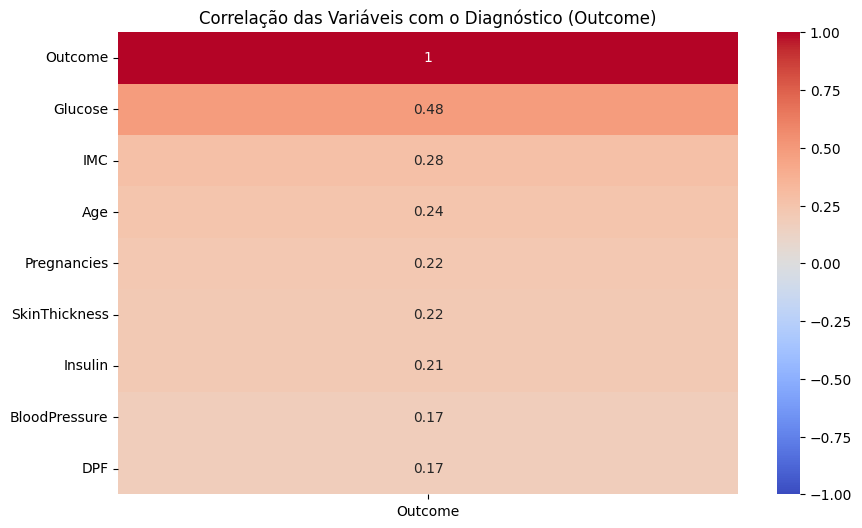

In [ ]:
# Identificar quais variáveis têm maior impacto no Resultado (Outcome)
plt.figure(figsize=(10, 6))
correlation_matrix = df_clean.corr()
sns.heatmap(correlation_matrix[['Outcome']].sort_values(by='Outcome', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlação das Variáveis com o Diagnóstico (Outcome)')
plt.show()

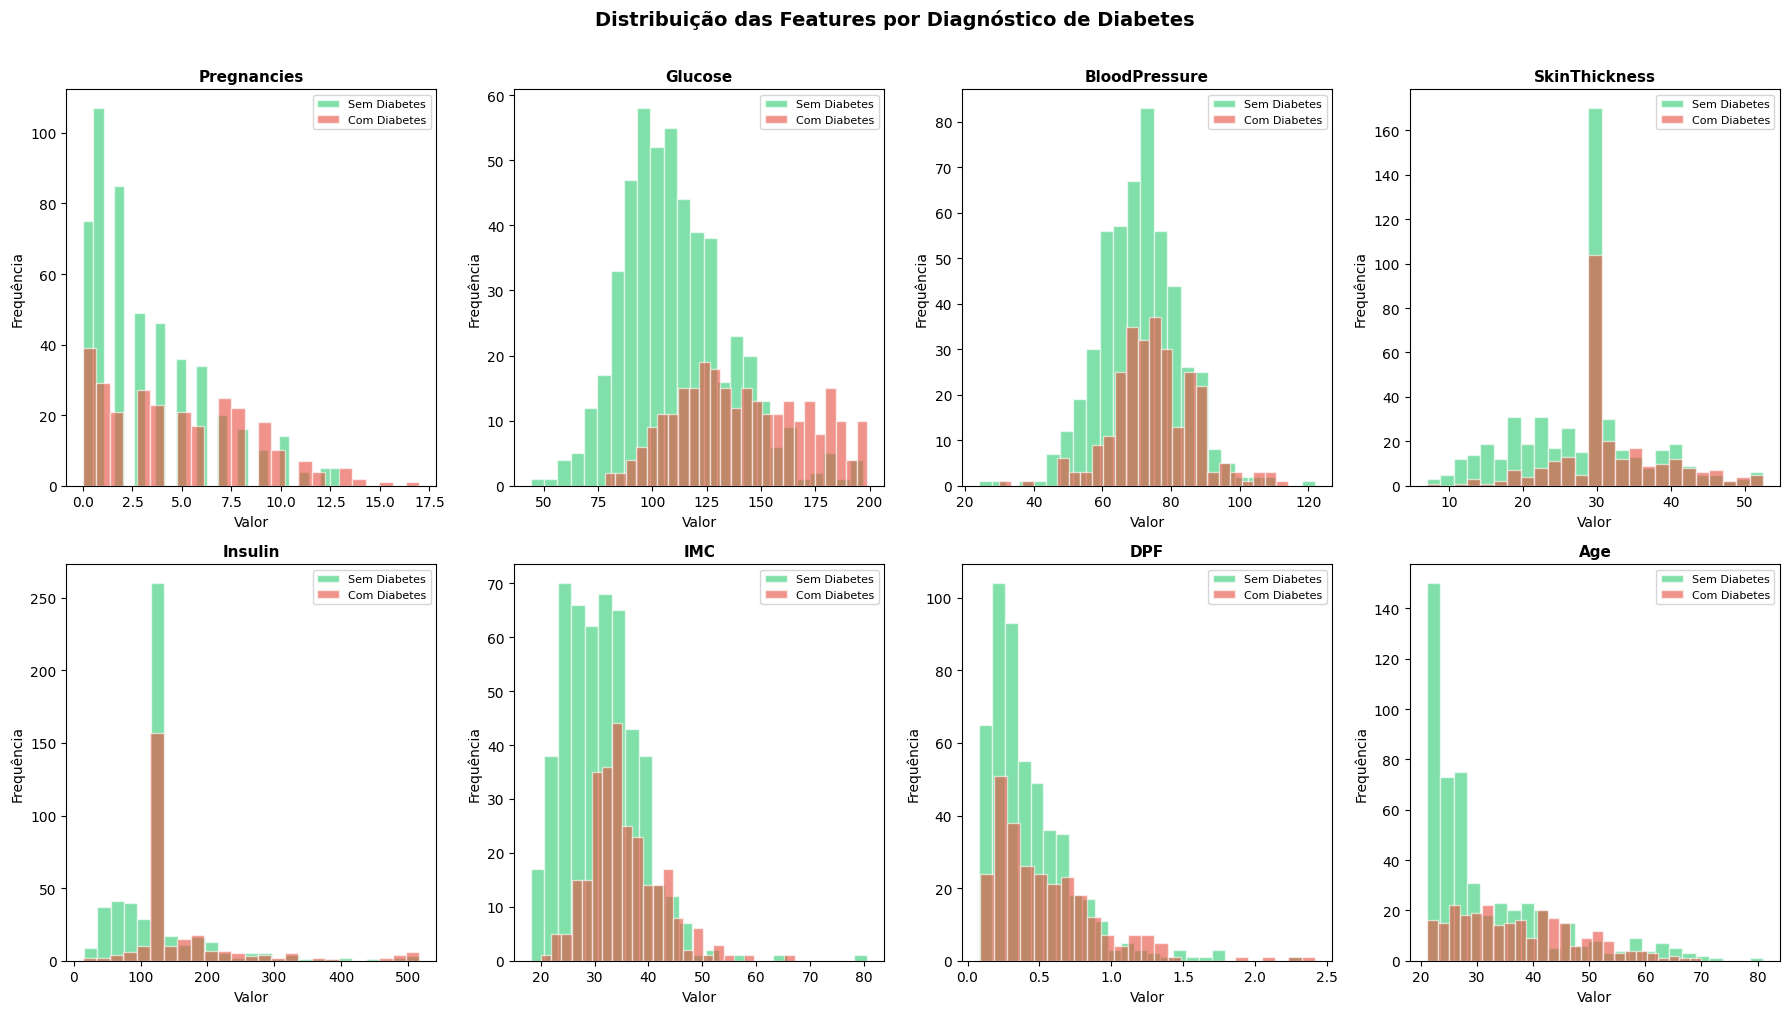

 Gráfico de distribuições gerado!


In [ ]:
# Distribuição de todas as features por classe
features = [c for c in df_clean.columns if c != 'Outcome']
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.ravel()
colors = ['#2ecc71', '#e74c3c']

for i, feature in enumerate(features):
    for outcome, color, label in zip([0, 1], colors, ['Sem Diabetes', 'Com Diabetes']):
        subset = df_clean[df_clean['Outcome'] == outcome][feature]
        axes[i].hist(subset, alpha=0.6, color=color, label=label, bins=25, edgecolor='white')
    axes[i].set_title(f'{feature}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frequência')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribuição das Features por Diagnóstico de Diabetes',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('distribuicao_features.png', bbox_inches='tight')
plt.show()
print(" Gráfico de distribuições gerado!")

## Conclusões até aqui

1.  **Qualidade Crítica (Dados Ocultos)**:
    *   Identificamos que **48.7% da coluna Insulin** e **29.5% da SkinThickness** são zeros. Como esses valores são biologicamente impossíveis, equivalem a valores nulos e foram substituídos pelas medianas, o que pode enviesar o resultado.
    *   O dataset está limpo, sem valores nulos ou duplicatas.

2.  **Análise de Outliers**:
    *   A variável **Insulin** apresenta valores extremos (até 846) que fogem muito da média (140).

3.  **Insights de Diagnóstico**:
    *   Glicose, IMC e Idade são os fatores com maior correlação positiva com o desfecho de diabetes.
    *   **Glicose** é o preditor mais forte (correção de ~0.47), seguido por **IMC** e **Idade**.
    *   As distribuições de violino e boxplots mostram uma separação clara nas medianas de Glicose entre pacientes saudáveis e diabéticos, validando a relevância dessa feature.
    * As visualizações confirmam que pacientes diabéticos tendem a apresentar níveis de glicose e IMC significativamente superiores.

In [ ]:
# A seguir, iremos separar todas as colunas na lista de ‘recursos’ para uma variável ‘X’ e a variável ‘destino’ para ‘y’.

X = df_clean.drop(columns=['Outcome'])
y = df_clean['Outcome']

X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,IMC,DPF,Age
0,6,148.0,72.0,35.0,126.0,33.6,0.627,50
1,1,85.0,66.0,29.0,126.0,26.6,0.351,31
2,8,183.0,64.0,29.0,126.0,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33


## Finalmente vamos treinar o modelo de dados

In [ ]:
from sklearn.model_selection import train_test_split

# test_size = guardar 20% dos valores
# a saída do método é constante, a ordenação muda de acordo com random_state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print(f"\n\nProporção de diagnósticos positivos e negativos para treino:\n{y_train.value_counts(normalize=True).map('{:.2%}'.format)}")

print(f"\n\nProporção de diagnósticos positivos e negativos para teste:\n{y_test.value_counts(normalize=True).map('{:.2%}'.format)}")



Proporção de diagnósticos positivos e negativos para treino:
Outcome
0    63.67%
1    36.33%
Name: proportion, dtype: object


Proporção de diagnósticos positivos e negativos para teste:
Outcome
0    70.51%
1    29.49%
Name: proportion, dtype: object


## De acordo com o material de estudo a Regressão Logística é recomendável para predizer targets booleanos, porém iremos testar outros modelos para comparar a eficiência

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

modelos = {
    "Regressão Logistica": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

resultados = []

In [ ]:
for nome, modelo in modelos.items():

    pipeline = Pipeline([
        ('scaler', StandardScaler()), # padronizando as escalas dos dados
        ('model', modelo)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    resultados.append({
        "Modelo": nome,
        "Acuracia": accuracy_score(y_test, y_pred), # Não é aconselhável utilizar como métrica, mas inseri para compararmos
        "Precisao": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred), # Quantos dos casos realmente positivos o modelo conseguiu identificar corretamente
        "F1": f1_score(y_test, y_pred)
    })

df_resultados = pd.DataFrame(resultados)
df_resultados.sort_values(by="F1", ascending=False)

,Modelo,Acuracia,Precisao,Recall,F1
2,SVM,0.788462,0.632653,0.673913,0.652632
0,Regressão Logistica,0.743590,0.557692,0.630435,0.591837
1,Random Forest,0.730769,0.535714,0.652174,0.588235
3,KNN,0.698718,0.491803,0.652174,0.560748


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Configurar Stratified K-Fold Cross-Validation
# Garante que cada fold tenha a mesma proporção de classes que o dataset original
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_resultados = []

for nome, modelo in modelos.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', modelo)
    ])

    # Executar validação cruzada para diferentes métricas
    accuracy_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='accuracy', n_jobs=-1)
    precision_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='precision', n_jobs=-1)
    recall_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='recall', n_jobs=-1)
    f1_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='f1', n_jobs=-1)

    cv_resultados.append({
        "Modelo": nome,
        "Acuracia_CV": accuracy_scores.mean(),
        "Precisao_CV": precision_scores.mean(),
        "Recall_CV": recall_scores.mean(),
        "F1_CV": f1_scores.mean()
    })

df_cv_resultados = pd.DataFrame(cv_resultados)
print("\nResultados da Validação Cruzada (Média dos Scores):")
display(df_cv_resultados.sort_values(by="F1_CV", ascending=False))


Resultados da Validação Cruzada (Média dos Scores):


,Modelo,Acuracia_CV,Precisao_CV,Recall_CV,F1_CV
1,Random Forest,0.760959,0.680107,0.599125,0.641941
3,KNN,0.742961,0.648753,0.584242,0.613506
2,SVM,0.762217,0.715848,0.540000,0.612181
0,Regressão Logistica,0.758371,0.704353,0.540067,0.608179


### Comparação dos resultados com e sem validação cruzada

In [ ]:
df_comparacao = df_resultados.set_index('Modelo').join(df_cv_resultados.set_index('Modelo'))
display(df_comparacao)

,Acuracia,Precisao,Recall,F1,Acuracia_CV,Precisao_CV,Recall_CV,F1_CV
Modelo,,,,,,,,
Regressão Logistica,0.743590,0.557692,0.630435,0.591837,0.758371,0.704353,0.540067,0.608179
Random Forest,0.730769,0.535714,0.652174,0.588235,0.760959,0.680107,0.599125,0.641941
SVM,0.788462,0.632653,0.673913,0.652632,0.762217,0.715848,0.540000,0.612181
KNN,0.698718,0.491803,0.652174,0.560748,0.742961,0.648753,0.584242,0.613506


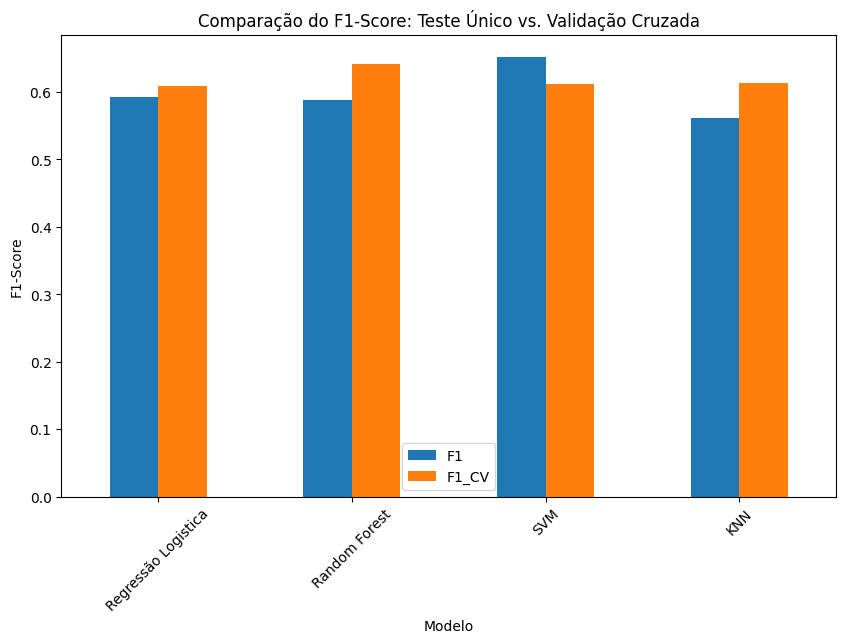

In [ ]:
df_comparacao[['F1', 'F1_CV']].plot(kind='bar', figsize=(10,6))
plt.title('Comparação do F1-Score: Teste Único vs. Validação Cruzada')
plt.ylabel('F1-Score')
plt.xticks(rotation=45)
plt.show()


Modelo: Regressão Logistica


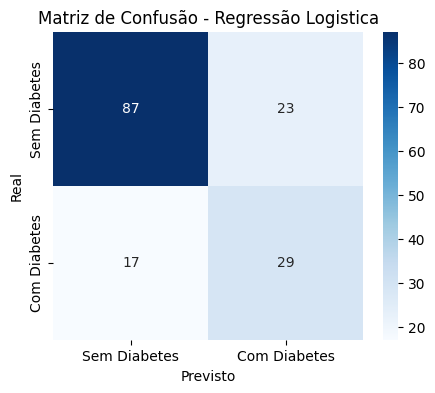


Modelo: Random Forest


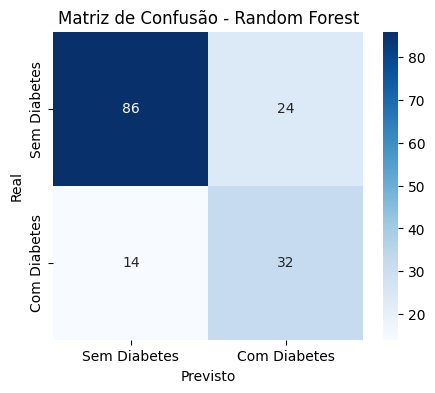


Modelo: SVM


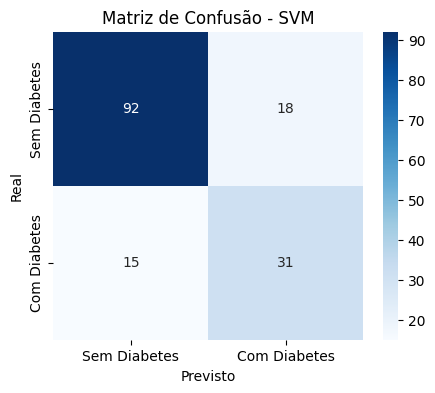


Modelo: KNN


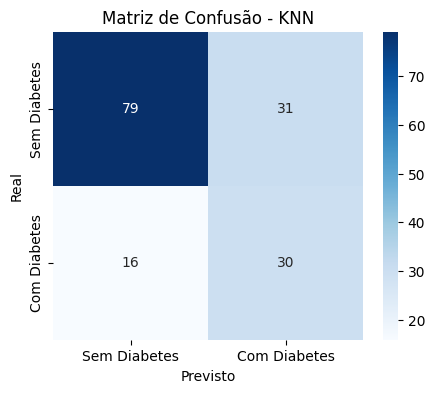

In [ ]:
from sklearn.metrics import confusion_matrix

for nome, modelo in modelos.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', modelo)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    print(f"\nModelo: {nome}")

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Sem Diabetes', 'Com Diabetes'],
        yticklabels=['Sem Diabetes', 'Com Diabetes']
    )
    plt.xlabel("Previsto")
    plt.ylabel("Real")
    plt.title(f"Matriz de Confusão - {nome}")
    plt.show()

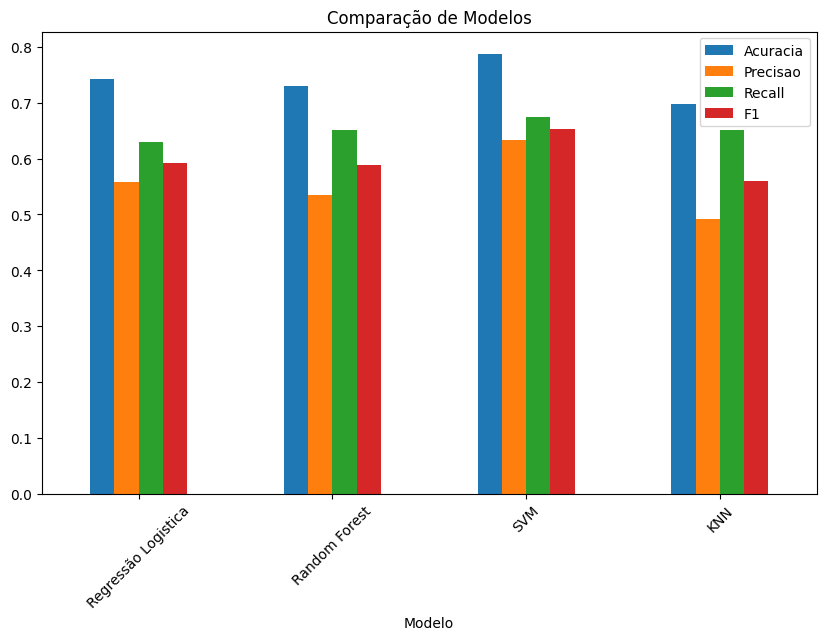

In [ ]:
df_resultados.set_index("Modelo")[["Acuracia", "Precisao", "Recall", "F1"]].plot(kind="bar", figsize=(10,6))
plt.title("Comparação de Modelos")
plt.xticks(rotation=45)
plt.show()